In [1]:
import os
import gc
import random
import zipfile
import warnings
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    roc_auc_score,
    accuracy_score,
    average_precision_score,
    log_loss,
    f1_score,
    precision_score,
    recall_score,
    roc_curve,
    precision_recall_curve,
    confusion_matrix,
    brier_score_loss
)

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

warnings.filterwarnings("ignore")

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

print("PyTorch version:", torch.__version__)
print("Device:", "cuda" if torch.cuda.is_available() else "cpu")

PyTorch version: 2.12.1+cpu
Device: cpu


In [2]:
DEVICE = torch.device("cpu")
print("Using:", DEVICE)

Using: cpu


In [6]:
from pathlib import Path

DATA_ROOT = Path(
    r"C:\Users\shrey\OneDrive\Desktop\MY_Project\wec_rec_tasks\Shreyash-Intelligence-SIG-Recs-2026\mandatory-tasks\recommender-systems-cf-to-dlrm\datasets"
)

print("Dataset folder:")
print(DATA_ROOT)

print("\nFiles:")

for f in DATA_ROOT.iterdir():
    print(f.name)


zip_files = list(DATA_ROOT.glob("*.zip"))

print("ZIP files found:")
for f in zip_files:
    print(f)

Dataset folder:
C:\Users\shrey\OneDrive\Desktop\MY_Project\wec_rec_tasks\Shreyash-Intelligence-SIG-Recs-2026\mandatory-tasks\recommender-systems-cf-to-dlrm\datasets

Files:
dataset (tasks 2 and 3).zip
README.md
ZIP files found:
C:\Users\shrey\OneDrive\Desktop\MY_Project\wec_rec_tasks\Shreyash-Intelligence-SIG-Recs-2026\mandatory-tasks\recommender-systems-cf-to-dlrm\datasets\dataset (tasks 2 and 3).zip


In [7]:
ZIP_PATH = zip_files[0]

EXTRACT_DIR = DATA_ROOT / "task2_3_data"

if not EXTRACT_DIR.exists():
    EXTRACT_DIR.mkdir(parents=True)

    with zipfile.ZipFile(ZIP_PATH, "r") as z:
        z.extractall(EXTRACT_DIR)

print("Extracted to:", EXTRACT_DIR.resolve())

Extracted to: C:\Users\shrey\OneDrive\Desktop\MY_Project\wec_rec_tasks\Shreyash-Intelligence-SIG-Recs-2026\mandatory-tasks\recommender-systems-cf-to-dlrm\datasets\task2_3_data


In [8]:
all_files = []

for root, dirs, files in os.walk(EXTRACT_DIR):
    for file in files:
        all_files.append(Path(root) / file)

for f in all_files:
    print(f)

C:\Users\shrey\OneDrive\Desktop\MY_Project\wec_rec_tasks\Shreyash-Intelligence-SIG-Recs-2026\mandatory-tasks\recommender-systems-cf-to-dlrm\datasets\task2_3_data\test.csv
C:\Users\shrey\OneDrive\Desktop\MY_Project\wec_rec_tasks\Shreyash-Intelligence-SIG-Recs-2026\mandatory-tasks\recommender-systems-cf-to-dlrm\datasets\task2_3_data\train.csv


In [9]:
train_candidates = [
    f for f in all_files
    if "train" in f.name.lower()
]

test_candidates = [
    f for f in all_files
    if "test" in f.name.lower()
]

print("Train candidates:")
for f in train_candidates:
    print(f)

print("\nTest candidates:")
for f in test_candidates:
    print(f)

Train candidates:
C:\Users\shrey\OneDrive\Desktop\MY_Project\wec_rec_tasks\Shreyash-Intelligence-SIG-Recs-2026\mandatory-tasks\recommender-systems-cf-to-dlrm\datasets\task2_3_data\train.csv

Test candidates:
C:\Users\shrey\OneDrive\Desktop\MY_Project\wec_rec_tasks\Shreyash-Intelligence-SIG-Recs-2026\mandatory-tasks\recommender-systems-cf-to-dlrm\datasets\task2_3_data\test.csv


In [10]:
TRAIN_PATH = train_candidates[0]
TEST_PATH = test_candidates[0]

print("TRAIN:", TRAIN_PATH)
print("TEST :", TEST_PATH)

TRAIN: C:\Users\shrey\OneDrive\Desktop\MY_Project\wec_rec_tasks\Shreyash-Intelligence-SIG-Recs-2026\mandatory-tasks\recommender-systems-cf-to-dlrm\datasets\task2_3_data\train.csv
TEST : C:\Users\shrey\OneDrive\Desktop\MY_Project\wec_rec_tasks\Shreyash-Intelligence-SIG-Recs-2026\mandatory-tasks\recommender-systems-cf-to-dlrm\datasets\task2_3_data\test.csv


In [11]:
train_df = pd.read_csv(TRAIN_PATH)
test_df = pd.read_csv(TEST_PATH)

In [12]:
print("Train shape:", train_df.shape)
print("Test shape :", test_df.shape)

display(train_df.head())

Train shape: (40000, 40)
Test shape : (10000, 40)


,label,integer_feature_1,integer_feature_2,integer_feature_3,integer_feature_4,integer_feature_5,integer_feature_6,integer_feature_7,integer_feature_8,integer_feature_9,...,categorical_feature_17,categorical_feature_18,categorical_feature_19,categorical_feature_20,categorical_feature_21,categorical_feature_22,categorical_feature_23,categorical_feature_24,categorical_feature_25,categorical_feature_26
0,0,49.0,520.0,0.0,353.0,5.0,0.0,0.0,0,2,...,1f7fc70b,628f1b8d,9512c20b,c5362157,a9ad4e8e,2b6a4b2f,bc71cd9d,9f4102b0,ff654802,2f33557c
1,0,NaN,408.0,NaN,NaN,NaN,0.0,0.0,-1,1,...,NaN,a1eb1511,0a1d513f,7fdb0729,747f6ecc,62682372,NaN,401a16fe,30436bfc,b757e957
2,0,28.0,37.0,2.0,5.0,4.0,5.0,1.0,974,14,...,753da5f3,d9f758ff,9512c20b,682d90ba,09afda28,307a0f03,f942364c,16e6b497,57e36578,a7ab145d
3,0,1.0,603.0,1.0,NaN,1.0,0.0,0.0,13,1,...,NaN,b8170bba,108a0699,47849e55,73b3f46d,d994ba60,NaN,328e967b,ff654802,2ba8d787
4,0,NaN,525.0,3.0,8.0,126.0,1.0,0.0,10,11,...,753da5f3,b8170bba,55191c09,0e29b5da,0683bc6f,47b99d80,d2b125b2,00a688ec,30436bfc,b757e957


In [13]:
print(train_df.dtypes)

print("\nMissing values:")
display(train_df.isna().sum().sort_values(ascending=False).head(20))

label                       int64
integer_feature_1         float64
integer_feature_2         float64
integer_feature_3         float64
integer_feature_4         float64
integer_feature_5         float64
integer_feature_6         float64
integer_feature_7         float64
integer_feature_8           int64
integer_feature_9           int64
integer_feature_10        float64
integer_feature_11        float64
integer_feature_12        float64
integer_feature_13        float64
categorical_feature_1         str
categorical_feature_2         str
categorical_feature_3         str
categorical_feature_4         str
categorical_feature_5         str
categorical_feature_6         str
categorical_feature_7         str
categorical_feature_8         str
categorical_feature_9         str
categorical_feature_10        str
categorical_feature_11        str
categorical_feature_12        str
categorical_feature_13        str
categorical_feature_14        str
categorical_feature_15        str
categorical_fe

integer_feature_4         15995
integer_feature_5         15413
integer_feature_11        15413
categorical_feature_17    14543
categorical_feature_14    14543
categorical_feature_16    14543
categorical_feature_23    14543
integer_feature_3          9817
integer_feature_13         9817
integer_feature_1          7396
integer_feature_10         3527
integer_feature_6          3527
integer_feature_2          3476
categorical_feature_20     1621
categorical_feature_11     1621
categorical_feature_1      1621
categorical_feature_10     1621
categorical_feature_21     1621
categorical_feature_22     1621
integer_feature_7          1213
dtype: int64

In [14]:
possible_targets = [
    c for c in train_df.columns
    if c.lower() in ["label", "click", "target", "clicked", "y"]
]

print(possible_targets)

['label']


label
0    38720
1     1280
Name: count, dtype: int64

label
0    0.968
1    0.032
Name: proportion, dtype: float64


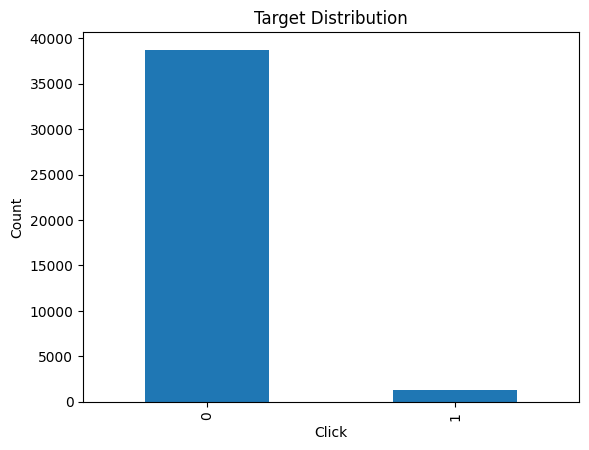

In [15]:
TARGET = "label"

print(train_df[TARGET].value_counts())
print()
print(train_df[TARGET].value_counts(normalize=True))


train_df[TARGET].value_counts().plot(kind="bar")

plt.title("Target Distribution")
plt.xlabel("Click")
plt.ylabel("Count")
plt.show()

In [17]:
from sklearn.model_selection import train_test_split

X = train_df.drop(columns=[TARGET])
y = train_df[TARGET].astype(np.int8)

X_test = test_df.copy()

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training shape  :", X_train.shape)
print("Validation shape:", X_val.shape)
print("Test shape      :", X_test.shape)

Training shape  : (32000, 39)
Validation shape: (8000, 39)
Test shape      : (10000, 40)


In [18]:
print("Original positive rate :",
      y.mean())

print("Train positive rate    :",
      y_train.mean())

print("Validation positive rate:",
      y_val.mean())

Original positive rate : 0.032
Train positive rate    : 0.032
Validation positive rate: 0.032


In [19]:
categorical_cols = X_train.select_dtypes(
    include=["object", "category"]
).columns.tolist()

numerical_cols = [
    col for col in X_train.columns
    if col not in categorical_cols
]

print("Number of numerical features :", len(numerical_cols))
print("Number of categorical features:", len(categorical_cols))

print("\nNumerical columns:")
print(numerical_cols)

print("\nCategorical columns:")
print(categorical_cols)

Number of numerical features : 13
Number of categorical features: 26

Numerical columns:
['integer_feature_1', 'integer_feature_2', 'integer_feature_3', 'integer_feature_4', 'integer_feature_5', 'integer_feature_6', 'integer_feature_7', 'integer_feature_8', 'integer_feature_9', 'integer_feature_10', 'integer_feature_11', 'integer_feature_12', 'integer_feature_13']

Categorical columns:
['categorical_feature_1', 'categorical_feature_2', 'categorical_feature_3', 'categorical_feature_4', 'categorical_feature_5', 'categorical_feature_6', 'categorical_feature_7', 'categorical_feature_8', 'categorical_feature_9', 'categorical_feature_10', 'categorical_feature_11', 'categorical_feature_12', 'categorical_feature_13', 'categorical_feature_14', 'categorical_feature_15', 'categorical_feature_16', 'categorical_feature_17', 'categorical_feature_18', 'categorical_feature_19', 'categorical_feature_20', 'categorical_feature_21', 'categorical_feature_22', 'categorical_feature_23', 'categorical_feature_

In [20]:
print("Numerical missing values:")
display(
    X_train[numerical_cols]
    .isna()
    .sum()
    .sort_values(ascending=False)
)

print("\nCategorical missing values:")
display(
    X_train[categorical_cols]
    .isna()
    .sum()
    .sort_values(ascending=False)
)

Numerical missing values:


integer_feature_4     12844
integer_feature_5     12388
integer_feature_11    12388
integer_feature_13     7865
integer_feature_3      7865
integer_feature_1      5907
integer_feature_6      2829
integer_feature_10     2829
integer_feature_2      2788
integer_feature_7       975
integer_feature_12       91
integer_feature_9         0
integer_feature_8         0
dtype: int64


Categorical missing values:


categorical_feature_16    11629
categorical_feature_14    11629
categorical_feature_23    11629
categorical_feature_17    11629
categorical_feature_22     1282
categorical_feature_21     1282
categorical_feature_11     1282
categorical_feature_20     1282
categorical_feature_1      1282
categorical_feature_10     1282
categorical_feature_9         0
categorical_feature_8         0
categorical_feature_7         0
categorical_feature_6         0
categorical_feature_4         0
categorical_feature_5         0
categorical_feature_3         0
categorical_feature_2         0
categorical_feature_18        0
categorical_feature_15        0
categorical_feature_12        0
categorical_feature_13        0
categorical_feature_19        0
categorical_feature_24        0
categorical_feature_25        0
categorical_feature_26        0
dtype: int64

In [21]:
numerical_medians = (
    X_train[numerical_cols]
    .median()
)

X_train_num = X_train[numerical_cols].copy()
X_val_num = X_val[numerical_cols].copy()
X_test_num = X_test[numerical_cols].copy()

X_train_num = X_train_num.fillna(numerical_medians)
X_val_num = X_val_num.fillna(numerical_medians)
X_test_num = X_test_num.fillna(numerical_medians)


In [22]:
# Standardization
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_num = scaler.fit_transform(
    X_train_num
)

X_val_num = scaler.transform(
    X_val_num
)

X_test_num = scaler.transform(
    X_test_num
)

In [23]:
X_train_num = X_train_num.astype(np.float32)
X_val_num = X_val_num.astype(np.float32)
X_test_num = X_test_num.astype(np.float32)

print(X_train_num.shape)
print(X_val_num.shape)
print(X_test_num.shape)

(32000, 13)
(8000, 13)
(10000, 13)


In [24]:
for col in categorical_cols:

    X_train[col] = (
        X_train[col]
        .fillna("__MISSING__")
        .astype(str)
    )

    X_val[col] = (
        X_val[col]
        .fillna("__MISSING__")
        .astype(str)
    )

    X_test[col] = (
        X_test[col]
        .fillna("__MISSING__")
        .astype(str)
    )

In [25]:
category_maps = {}
cardinalities = {}

for col in categorical_cols:

    unique_values = X_train[col].unique()

    mapping = {
        value: idx + 1
        for idx, value in enumerate(unique_values)
    }

    category_maps[col] = mapping

    # 0 = unknown category
    cardinalities[col] = len(mapping) + 1

print("Categorical cardinalities:\n")

for col in categorical_cols:
    print(
        f"{col:25s} -> "
        f"{cardinalities[col]} categories"
    )

Categorical cardinalities:

categorical_feature_1     -> 10858 categories
categorical_feature_2     -> 3349 categories
categorical_feature_3     -> 4586 categories
categorical_feature_4     -> 1614 categories
categorical_feature_5     -> 3643 categories
categorical_feature_6     -> 4 categories
categorical_feature_7     -> 2912 categories
categorical_feature_8     -> 711 categories
categorical_feature_9     -> 23 categories
categorical_feature_10    -> 9625 categories
categorical_feature_11    -> 4772 categories
categorical_feature_12    -> 6821 categories
categorical_feature_13    -> 10 categories
categorical_feature_14    -> 821 categories
categorical_feature_15    -> 1833 categories
categorical_feature_16    -> 43 categories
categorical_feature_17    -> 5 categories
categorical_feature_18    -> 310 categories
categorical_feature_19    -> 15 categories
categorical_feature_20    -> 11112 categories
categorical_feature_21    -> 7581 categories
categorical_feature_22    -> 10423 categor

In [26]:
def encode_categorical(
    df,
    categorical_cols,
    category_maps
):

    encoded = np.zeros(
        (len(df), len(categorical_cols)),
        dtype=np.int64
    )

    for j, col in enumerate(categorical_cols):

        values = (
            df[col]
            .fillna("__MISSING__")
            .astype(str)
        )

        mapping = category_maps[col]

        encoded[:, j] = [
            mapping.get(value, 0)
            for value in values
        ]

    return encoded

In [27]:
X_train_cat = encode_categorical(
    X_train,
    categorical_cols,
    category_maps
)

X_val_cat = encode_categorical(
    X_val,
    categorical_cols,
    category_maps
)

X_test_cat = encode_categorical(
    X_test,
    categorical_cols,
    category_maps
)

In [28]:
print("Train categorical:", X_train_cat.shape)
print("Validation categorical:", X_val_cat.shape)
print("Test categorical:", X_test_cat.shape)

Train categorical: (32000, 26)
Validation categorical: (8000, 26)
Test categorical: (10000, 26)


In [29]:
y_train_np = y_train.values.astype(np.float32)
y_val_np = y_val.values.astype(np.float32)

print(y_train_np.shape)
print(y_val_np.shape)

(32000,)
(8000,)


In [30]:
import torch
import torch.nn as nn

from torch.utils.data import Dataset, DataLoader

DEVICE = torch.device("cpu")

print("Using device:", DEVICE)

Using device: cpu


In [31]:
class CTRDataset(Dataset):

    def __init__(
        self,
        numerical,
        categorical,
        target=None
    ):

        self.numerical = torch.tensor(
            numerical,
            dtype=torch.float32
        )

        self.categorical = torch.tensor(
            categorical,
            dtype=torch.long
        )

        self.target = None

        if target is not None:

            self.target = torch.tensor(
                target,
                dtype=torch.float32
            )

    def __len__(self):
        return len(self.numerical)

    def __getitem__(self, idx):

        if self.target is not None:

            return (
                self.numerical[idx],
                self.categorical[idx],
                self.target[idx]
            )

        return (
            self.numerical[idx],
            self.categorical[idx]
        )

In [32]:
train_dataset = CTRDataset(
    X_train_num,
    X_train_cat,
    y_train_np
)

val_dataset = CTRDataset(
    X_val_num,
    X_val_cat,
    y_val_np
)

test_dataset = CTRDataset(
    X_test_num,
    X_test_cat
)

print("Train samples:", len(train_dataset))
print("Validation samples:", len(val_dataset))
print("Test samples:", len(test_dataset))

Train samples: 32000
Validation samples: 8000
Test samples: 10000


In [33]:
BATCH_SIZE = 2048

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

print("DataLoaders ready.")

DataLoaders ready.


In [34]:
def get_embedding_dim(cardinality):

    return min(
        32,
        max(
            4,
            int(np.sqrt(cardinality))
        )
    )

In [35]:
class CTRNet(nn.Module):

    def __init__(
        self,
        cardinalities,
        num_numerical,
        hidden_dims=(128, 64),
        dropout=0.2
    ):

        super().__init__()

        # -------------------------
        # Categorical embeddings
        # -------------------------

        self.embeddings = nn.ModuleList()

        embedding_dims = []

        for cardinality in cardinalities:

            emb_dim = get_embedding_dim(
                cardinality
            )

            self.embeddings.append(
                nn.Embedding(
                    cardinality,
                    emb_dim
                )
            )

            embedding_dims.append(
                emb_dim
            )

        total_embedding_dim = sum(
            embedding_dims
        )

        # -------------------------
        # MLP
        # -------------------------

        input_dim = (
            total_embedding_dim
            + num_numerical
        )

        layers = []

        prev_dim = input_dim

        for hidden_dim in hidden_dims:

            layers.append(
                nn.Linear(
                    prev_dim,
                    hidden_dim
                )
            )

            layers.append(
                nn.ReLU()
            )

            layers.append(
                nn.Dropout(dropout)
            )

            prev_dim = hidden_dim

        # Output = one logit

        layers.append(
            nn.Linear(
                prev_dim,
                1
            )
        )

        self.mlp = nn.Sequential(
            *layers
        )

    def forward(
        self,
        numerical,
        categorical
    ):

        embedded_features = []

        for i, embedding in enumerate(
            self.embeddings
        ):

            embedded = embedding(
                categorical[:, i]
            )

            embedded_features.append(
                embedded
            )

        categorical_vector = torch.cat(
            embedded_features,
            dim=1
        )

        x = torch.cat(
            [
                numerical,
                categorical_vector
            ],
            dim=1
        )

        output = self.mlp(x)

        return output.squeeze(1)

In [36]:
cardinality_list = [
    cardinalities[col]
    for col in categorical_cols
]

print(
    "Number of categorical features:",
    len(cardinality_list)
)

print(
    "Cardinalities:",
    cardinality_list
)

Number of categorical features: 26
Cardinalities: [10858, 3349, 4586, 1614, 3643, 4, 2912, 711, 23, 9625, 4772, 6821, 10, 821, 1833, 43, 5, 310, 15, 11112, 7581, 10423, 4362, 3258, 36, 25]


In [37]:
negative_count = (y_train == 0).sum()
positive_count = (y_train == 1).sum()

pos_weight_value = (
    negative_count /
    positive_count
)

print("Negative samples:", negative_count)
print("Positive samples:", positive_count)

print(
    "Positive class weight:",
    pos_weight_value
)

Negative samples: 30976
Positive samples: 1024
Positive class weight: 30.25


In [38]:
pos_weight = torch.tensor(
    [pos_weight_value],
    dtype=torch.float32
).to(DEVICE)

print(pos_weight)

tensor([30.2500])


In [39]:
def evaluate_model(
    model,
    loader,
    criterion
):

    model.eval()

    total_loss = 0.0
    total_samples = 0

    all_probs = []
    all_targets = []

    with torch.no_grad():

        for (
            numerical,
            categorical,
            target
        ) in loader:

            numerical = numerical.to(
                DEVICE
            )

            categorical = categorical.to(
                DEVICE
            )

            target = target.to(
                DEVICE
            )

            logits = model(
                numerical,
                categorical
            )

            loss = criterion(
                logits,
                target
            )

            probs = torch.sigmoid(
                logits
            )

            batch_size = target.size(0)

            total_loss += (
                loss.item()
                * batch_size
            )

            total_samples += batch_size

            all_probs.extend(
                probs.cpu().numpy()
            )

            all_targets.extend(
                target.cpu().numpy()
            )

    avg_loss = (
        total_loss /
        total_samples
    )

    y_true = np.asarray(
        all_targets
    )

    y_prob = np.asarray(
        all_probs
    )

    y_pred = (
        y_prob >= 0.5
    ).astype(int)

    roc_auc = roc_auc_score(
        y_true,
        y_prob
    )

    pr_auc = average_precision_score(
        y_true,
        y_prob
    )

    accuracy = accuracy_score(
        y_true,
        y_pred
    )

    f1 = f1_score(
        y_true,
        y_pred,
        zero_division=0
    )

    return {
        "loss": avg_loss,
        "roc_auc": roc_auc,
        "pr_auc": pr_auc,
        "accuracy": accuracy,
        "f1": f1,
        "y_true": y_true,
        "y_prob": y_prob
    }

In [40]:
def train_model(
    model,
    train_loader,
    val_loader,
    pos_weight,
    epochs=8,
    learning_rate=1e-3,
    weight_decay=1e-5,
    patience=2
):

    criterion = nn.BCEWithLogitsLoss(
        pos_weight=pos_weight
    )

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=learning_rate,
        weight_decay=weight_decay
    )

    history = {
        "train_loss": [],
        "val_loss": [],
        "train_auc": [],
        "val_auc": []
    }

    best_val_auc = -np.inf

    best_state = None

    patience_counter = 0

    for epoch in range(epochs):

        # =========================
        # TRAIN
        # =========================

        model.train()

        running_loss = 0.0
        total_samples = 0

        train_probs = []
        train_targets = []

        for (
            numerical,
            categorical,
            target
        ) in train_loader:

            numerical = numerical.to(
                DEVICE
            )

            categorical = categorical.to(
                DEVICE
            )

            target = target.to(
                DEVICE
            )

            optimizer.zero_grad()

            logits = model(
                numerical,
                categorical
            )

            loss = criterion(
                logits,
                target
            )

            loss.backward()

            optimizer.step()

            batch_size = target.size(0)

            running_loss += (
                loss.item()
                * batch_size
            )

            total_samples += batch_size

            train_probs.extend(
                torch.sigmoid(logits)
                .detach()
                .cpu()
                .numpy()
            )

            train_targets.extend(
                target
                .detach()
                .cpu()
                .numpy()
            )

        train_loss = (
            running_loss /
            total_samples
        )

        train_auc = roc_auc_score(
            train_targets,
            train_probs
        )

        # =========================
        # VALIDATION
        # =========================

        val_metrics = evaluate_model(
            model,
            val_loader,
            criterion
        )

        val_loss = val_metrics["loss"]

        val_auc = val_metrics["roc_auc"]

        # =========================
        # STORE HISTORY
        # =========================

        history["train_loss"].append(
            train_loss
        )

        history["val_loss"].append(
            val_loss
        )

        history["train_auc"].append(
            train_auc
        )

        history["val_auc"].append(
            val_auc
        )

        print(
            f"Epoch {epoch + 1}/{epochs} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Val Loss: {val_loss:.4f} | "
            f"Train AUC: {train_auc:.4f} | "
            f"Val AUC: {val_auc:.4f}"
        )

        # =========================
        # EARLY STOPPING
        # =========================

        if val_auc > best_val_auc:

            best_val_auc = val_auc

            best_state = {
                key: value.detach()
                .cpu()
                .clone()
                for key, value
                in model.state_dict().items()
            }

            patience_counter = 0

        else:

            patience_counter += 1

            if patience_counter >= patience:

                print(
                    "\nEarly stopping triggered."
                )

                break

    # Restore best model

    if best_state is not None:

        model.load_state_dict(
            best_state
        )

    return model, history

## Architecture 1 : small model

In [41]:
model_small = CTRNet(
    cardinalities=cardinality_list,
    num_numerical=len(numerical_cols),
    hidden_dims=(64, 32),
    dropout=0.15
).to(DEVICE)

print(model_small)

CTRNet(
  (embeddings): ModuleList(
    (0): Embedding(10858, 32)
    (1): Embedding(3349, 32)
    (2): Embedding(4586, 32)
    (3): Embedding(1614, 32)
    (4): Embedding(3643, 32)
    (5): Embedding(4, 4)
    (6): Embedding(2912, 32)
    (7): Embedding(711, 26)
    (8): Embedding(23, 4)
    (9): Embedding(9625, 32)
    (10): Embedding(4772, 32)
    (11): Embedding(6821, 32)
    (12): Embedding(10, 4)
    (13): Embedding(821, 28)
    (14): Embedding(1833, 32)
    (15): Embedding(43, 6)
    (16): Embedding(5, 4)
    (17): Embedding(310, 17)
    (18): Embedding(15, 4)
    (19): Embedding(11112, 32)
    (20): Embedding(7581, 32)
    (21): Embedding(10423, 32)
    (22): Embedding(4362, 32)
    (23): Embedding(3258, 32)
    (24): Embedding(36, 6)
    (25): Embedding(25, 5)
  )
  (mlp): Sequential(
    (0): Linear(in_features=601, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.15, inplace=False)
    (3): Linear(in_features=64, out_features=32, bias=True)
    (4): ReLU()
  

In [42]:
model_small, history_small = train_model(
    model_small,
    train_loader,
    val_loader,
    pos_weight=pos_weight,
    epochs=8,
    learning_rate=1e-3,
    weight_decay=1e-5,
    patience=2
)

Epoch 1/8 | Train Loss: 1.3337 | Val Loss: 1.3176 | Train AUC: 0.5448 | Val AUC: 0.6039
Epoch 2/8 | Train Loss: 1.2913 | Val Loss: 1.2907 | Train AUC: 0.6533 | Val AUC: 0.6461
Epoch 3/8 | Train Loss: 1.2278 | Val Loss: 1.2466 | Train AUC: 0.7181 | Val AUC: 0.6782
Epoch 4/8 | Train Loss: 1.1417 | Val Loss: 1.2485 | Train AUC: 0.7649 | Val AUC: 0.6853
Epoch 5/8 | Train Loss: 1.0408 | Val Loss: 1.3113 | Train AUC: 0.8123 | Val AUC: 0.6834
Epoch 6/8 | Train Loss: 0.9181 | Val Loss: 1.3638 | Train AUC: 0.8619 | Val AUC: 0.6789

Early stopping triggered.


In [43]:
criterion_weighted = nn.BCEWithLogitsLoss(
    pos_weight=pos_weight
)

small_metrics = evaluate_model(
    model_small,
    val_loader,
    criterion_weighted
)

print(
    f"ROC-AUC : {small_metrics['roc_auc']:.4f}"
)

print(
    f"PR-AUC  : {small_metrics['pr_auc']:.4f}"
)

print(
    f"Accuracy: {small_metrics['accuracy']:.4f}"
)

print(
    f"F1      : {small_metrics['f1']:.4f}"
)

print(
    f"Log Loss: "
    f"{log_loss(small_metrics['y_true'], small_metrics['y_prob']):.4f}"
)

ROC-AUC : 0.6853
PR-AUC  : 0.0749
Accuracy: 0.7125
F1      : 0.1106
Log Loss: 0.5685


## Architecture 2 : medium model

In [44]:
model_medium = CTRNet(
    cardinalities=cardinality_list,
    num_numerical=len(numerical_cols),
    hidden_dims=(128, 64),
    dropout=0.20
).to(DEVICE)

print(model_medium)

CTRNet(
  (embeddings): ModuleList(
    (0): Embedding(10858, 32)
    (1): Embedding(3349, 32)
    (2): Embedding(4586, 32)
    (3): Embedding(1614, 32)
    (4): Embedding(3643, 32)
    (5): Embedding(4, 4)
    (6): Embedding(2912, 32)
    (7): Embedding(711, 26)
    (8): Embedding(23, 4)
    (9): Embedding(9625, 32)
    (10): Embedding(4772, 32)
    (11): Embedding(6821, 32)
    (12): Embedding(10, 4)
    (13): Embedding(821, 28)
    (14): Embedding(1833, 32)
    (15): Embedding(43, 6)
    (16): Embedding(5, 4)
    (17): Embedding(310, 17)
    (18): Embedding(15, 4)
    (19): Embedding(11112, 32)
    (20): Embedding(7581, 32)
    (21): Embedding(10423, 32)
    (22): Embedding(4362, 32)
    (23): Embedding(3258, 32)
    (24): Embedding(36, 6)
    (25): Embedding(25, 5)
  )
  (mlp): Sequential(
    (0): Linear(in_features=601, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
 

In [45]:
model_medium, history_medium = train_model(
    model_medium,
    train_loader,
    val_loader,
    pos_weight=pos_weight,
    epochs=8,
    learning_rate=1e-3,
    weight_decay=1e-5,
    patience=2
)

Epoch 1/8 | Train Loss: 1.3341 | Val Loss: 1.3106 | Train AUC: 0.5498 | Val AUC: 0.6156
Epoch 2/8 | Train Loss: 1.2793 | Val Loss: 1.2689 | Train AUC: 0.6675 | Val AUC: 0.6781
Epoch 3/8 | Train Loss: 1.1963 | Val Loss: 1.2378 | Train AUC: 0.7409 | Val AUC: 0.6870
Epoch 4/8 | Train Loss: 1.1120 | Val Loss: 1.2756 | Train AUC: 0.7792 | Val AUC: 0.6800
Epoch 5/8 | Train Loss: 0.9760 | Val Loss: 1.3618 | Train AUC: 0.8432 | Val AUC: 0.6621

Early stopping triggered.


In [46]:
medium_metrics = evaluate_model(
    model_medium,
    val_loader,
    criterion_weighted
)

print(
    f"ROC-AUC : {medium_metrics['roc_auc']:.4f}"
)

print(
    f"PR-AUC  : {medium_metrics['pr_auc']:.4f}"
)

print(
    f"Accuracy: {medium_metrics['accuracy']:.4f}"
)

print(
    f"F1      : {medium_metrics['f1']:.4f}"
)

print(
    f"Log Loss: "
    f"{log_loss(medium_metrics['y_true'], medium_metrics['y_prob']):.4f}"
)

ROC-AUC : 0.6870
PR-AUC  : 0.0669
Accuracy: 0.6880
F1      : 0.1060
Log Loss: 0.6205


## Architecture 3 : Regularized model

In [47]:
model_regularized = CTRNet(
    cardinalities=cardinality_list,
    num_numerical=len(numerical_cols),
    hidden_dims=(128, 64, 32),
    dropout=0.30
).to(DEVICE)

print(model_regularized)

CTRNet(
  (embeddings): ModuleList(
    (0): Embedding(10858, 32)
    (1): Embedding(3349, 32)
    (2): Embedding(4586, 32)
    (3): Embedding(1614, 32)
    (4): Embedding(3643, 32)
    (5): Embedding(4, 4)
    (6): Embedding(2912, 32)
    (7): Embedding(711, 26)
    (8): Embedding(23, 4)
    (9): Embedding(9625, 32)
    (10): Embedding(4772, 32)
    (11): Embedding(6821, 32)
    (12): Embedding(10, 4)
    (13): Embedding(821, 28)
    (14): Embedding(1833, 32)
    (15): Embedding(43, 6)
    (16): Embedding(5, 4)
    (17): Embedding(310, 17)
    (18): Embedding(15, 4)
    (19): Embedding(11112, 32)
    (20): Embedding(7581, 32)
    (21): Embedding(10423, 32)
    (22): Embedding(4362, 32)
    (23): Embedding(3258, 32)
    (24): Embedding(36, 6)
    (25): Embedding(25, 5)
  )
  (mlp): Sequential(
    (0): Linear(in_features=601, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
 

In [48]:
model_regularized, history_regularized = train_model(
    model_regularized,
    train_loader,
    val_loader,
    pos_weight=pos_weight,
    epochs=8,
    learning_rate=1e-3,
    weight_decay=1e-5,
    patience=2
)

Epoch 1/8 | Train Loss: 1.3320 | Val Loss: 1.3250 | Train AUC: 0.5644 | Val AUC: 0.5981
Epoch 2/8 | Train Loss: 1.3109 | Val Loss: 1.2958 | Train AUC: 0.6223 | Val AUC: 0.6426
Epoch 3/8 | Train Loss: 1.2615 | Val Loss: 1.2618 | Train AUC: 0.6771 | Val AUC: 0.6694
Epoch 4/8 | Train Loss: 1.1871 | Val Loss: 1.2585 | Train AUC: 0.7279 | Val AUC: 0.6783
Epoch 5/8 | Train Loss: 1.0957 | Val Loss: 1.2629 | Train AUC: 0.7819 | Val AUC: 0.6849
Epoch 6/8 | Train Loss: 0.9720 | Val Loss: 1.3453 | Train AUC: 0.8405 | Val AUC: 0.6703
Epoch 7/8 | Train Loss: 0.8241 | Val Loss: 1.5208 | Train AUC: 0.8895 | Val AUC: 0.6666

Early stopping triggered.


In [49]:
regularized_metrics = evaluate_model(
    model_regularized,
    val_loader,
    criterion_weighted
)

print(
    f"ROC-AUC : {regularized_metrics['roc_auc']:.4f}"
)

print(
    f"PR-AUC  : {regularized_metrics['pr_auc']:.4f}"
)

print(
    f"Accuracy: {regularized_metrics['accuracy']:.4f}"
)

print(
    f"F1      : {regularized_metrics['f1']:.4f}"
)

print(
    f"Log Loss: "
    f"{log_loss(regularized_metrics['y_true'], regularized_metrics['y_prob']):.4f}"
)

ROC-AUC : 0.6849
PR-AUC  : 0.0717
Accuracy: 0.6650
F1      : 0.1055
Log Loss: 0.6698


In [50]:
results = []

for name, metrics in [
    ("Small", small_metrics),
    ("Medium", medium_metrics),
    ("Regularized", regularized_metrics)
]:

    results.append({

        "Architecture": name,

        "ROC-AUC":
            metrics["roc_auc"],

        "PR-AUC":
            metrics["pr_auc"],

        "Accuracy":
            metrics["accuracy"],

        "F1":
            metrics["f1"],

        "Log Loss":
            log_loss(
                metrics["y_true"],
                metrics["y_prob"]
            )
    })

results_df = pd.DataFrame(results)

display(
    results_df.sort_values(
        "ROC-AUC",
        ascending=False
    ).reset_index(drop=True)
)

,Architecture,ROC-AUC,PR-AUC,Accuracy,F1,Log Loss
0,Medium,0.687050,0.066866,0.6880,0.106017,0.620450
1,Small,0.685309,0.074899,0.7125,0.110596,0.568486
2,Regularized,0.684869,0.071702,0.6650,0.105474,0.669760


In [51]:
best_architecture = (
    results_df
    .loc[
        results_df["ROC-AUC"].idxmax(),
        "Architecture"
    ]
)

print(
    "Selected architecture:",
    best_architecture
)

Selected architecture: Medium


In [52]:
model_map = {
    "Small": model_small,
    "Medium": model_medium,
    "Regularized": model_regularized
}

history_map = {
    "Small": history_small,
    "Medium": history_medium,
    "Regularized": history_regularized
}

best_model = model_map[
    best_architecture
]

best_history = history_map[
    best_architecture
]

In [53]:
best_val_metrics = evaluate_model(
    best_model,
    val_loader,
    criterion_weighted
)

y_val_true = (
    best_val_metrics["y_true"]
)

y_val_prob = (
    best_val_metrics["y_prob"]
)

In [54]:
thresholds = np.arange(
    0.05,
    0.96,
    0.01
)

threshold_results = []

for threshold in thresholds:

    y_pred = (
        y_val_prob >= threshold
    ).astype(int)

    threshold_results.append({

        "Threshold": threshold,

        "F1": f1_score(
            y_val_true,
            y_pred,
            zero_division=0
        ),

        "Precision": precision_score(
            y_val_true,
            y_pred,
            zero_division=0
        ),

        "Recall": recall_score(
            y_val_true,
            y_pred,
            zero_division=0
        ),

        "Accuracy": accuracy_score(
            y_val_true,
            y_pred
        )
    })

threshold_df = pd.DataFrame(
    threshold_results
)

display(
    threshold_df
    .sort_values(
        "F1",
        ascending=False
    )
    .head(10)
)

,Threshold,F1,Precision,Recall,Accuracy
66,0.71,0.134670,0.106335,0.183594,0.924500
65,0.70,0.129555,0.098969,0.187500,0.919375
67,0.72,0.128440,0.105528,0.164062,0.928750
63,0.68,0.123687,0.088186,0.207031,0.906125
68,0.73,0.123377,0.105556,0.148438,0.932500
64,0.69,0.122807,0.090406,0.191406,0.912500
62,0.67,0.121475,0.084084,0.218750,0.898750
69,0.74,0.116814,0.106796,0.128906,0.937625
54,0.59,0.115783,0.068592,0.371094,0.818625
56,0.61,0.115679,0.070399,0.324219,0.841375


In [55]:
best_threshold = (
    threshold_df
    .loc[
        threshold_df["F1"].idxmax(),
        "Threshold"
    ]
)

print(
    f"Selected threshold: "
    f"{best_threshold:.2f}"
)

Selected threshold: 0.71


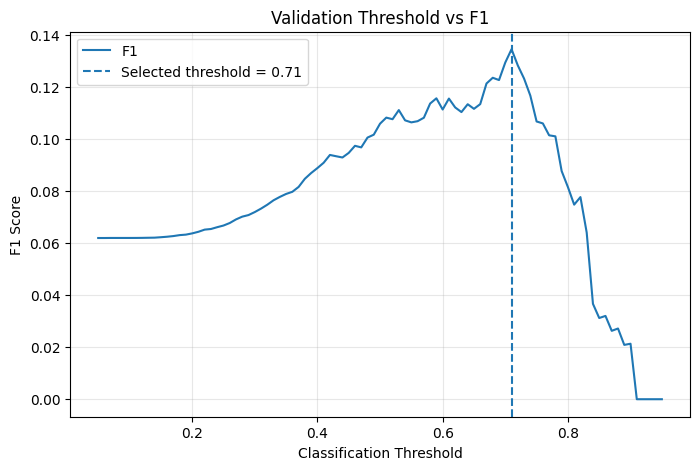

In [56]:
plt.figure(figsize=(8, 5))

plt.plot(
    threshold_df["Threshold"],
    threshold_df["F1"],
    label="F1"
)

plt.axvline(
    best_threshold,
    linestyle="--",
    label=(
        f"Selected threshold = "
        f"{best_threshold:.2f}"
    )
)

plt.xlabel("Classification Threshold")
plt.ylabel("F1 Score")

plt.title(
    "Validation Threshold vs F1"
)

plt.legend()
plt.grid(alpha=0.3)

plt.show()

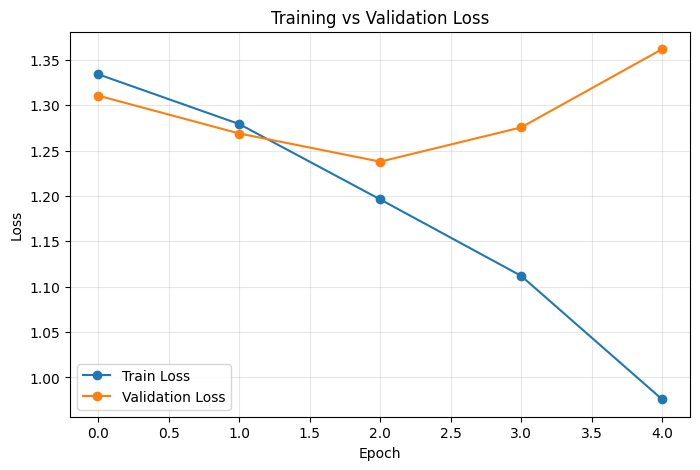

In [57]:
## Training Loss Curve

plt.figure(figsize=(8, 5))

plt.plot(
    best_history["train_loss"],
    marker="o",
    label="Train Loss"
)

plt.plot(
    best_history["val_loss"],
    marker="o",
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title(
    "Training vs Validation Loss"
)

plt.legend()
plt.grid(alpha=0.3)

plt.show()

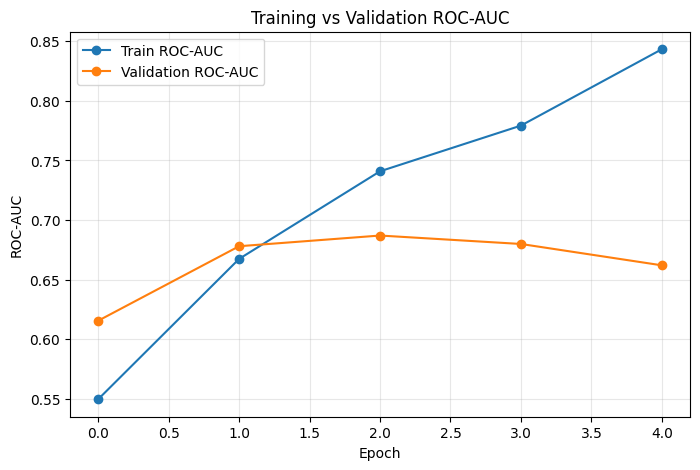

In [58]:
plt.figure(figsize=(8, 5))

plt.plot(
    best_history["train_auc"],
    marker="o",
    label="Train ROC-AUC"
)

plt.plot(
    best_history["val_auc"],
    marker="o",
    label="Validation ROC-AUC"
)

plt.xlabel("Epoch")
plt.ylabel("ROC-AUC")

plt.title(
    "Training vs Validation ROC-AUC"
)

plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [59]:
print(
    "Best validation ROC-AUC:",
    max(best_history["val_auc"])
)

print(
    "Final training ROC-AUC:",
    best_history["train_auc"][-1]
)

print(
    "Final validation ROC-AUC:",
    best_history["val_auc"][-1]
)

Best validation ROC-AUC: 0.6870495504584194
Final training ROC-AUC: 0.8432322415438567
Final validation ROC-AUC: 0.6620710388688016


## Test data predictions

In [60]:
best_model.eval()

test_probs = []

with torch.no_grad():

    for numerical, categorical in test_loader:

        numerical = numerical.to(
            DEVICE
        )

        categorical = categorical.to(
            DEVICE
        )

        logits = best_model(
            numerical,
            categorical
        )

        probs = torch.sigmoid(
            logits
        )

        test_probs.extend(
            probs.cpu().numpy()
        )

test_probs = np.asarray(
    test_probs
)

print(
    "Test predictions:",
    test_probs.shape
)

Test predictions: (10000,)


In [61]:
if TARGET in test_df.columns:

    y_test = (
        test_df[TARGET]
        .astype(int)
        .values
    )

    test_predictions = (
        test_probs >= best_threshold
    ).astype(int)

    test_roc_auc = roc_auc_score(
        y_test,
        test_probs
    )

    test_pr_auc = average_precision_score(
        y_test,
        test_probs
    )

    test_accuracy = accuracy_score(
        y_test,
        test_predictions
    )

    test_f1 = f1_score(
        y_test,
        test_predictions,
        zero_division=0
    )

    test_precision = precision_score(
        y_test,
        test_predictions,
        zero_division=0
    )

    test_recall = recall_score(
        y_test,
        test_predictions,
        zero_division=0
    )

    test_log_loss = log_loss(
        y_test,
        test_probs
    )

    print(
        f"ROC-AUC : {test_roc_auc:.4f}"
    )

    print(
        f"PR-AUC  : {test_pr_auc:.4f}"
    )

    print(
        f"Accuracy: {test_accuracy:.4f}"
    )

    print(
        f"F1      : {test_f1:.4f}"
    )

    print(
        f"Precision: {test_precision:.4f}"
    )

    print(
        f"Recall   : {test_recall:.4f}"
    )

    print(
        f"Log Loss : {test_log_loss:.4f}"
    )

ROC-AUC : 0.6509
PR-AUC  : 0.0628
Accuracy: 0.9269
F1      : 0.1009
Precision: 0.0858
Recall   : 0.1224
Log Loss : 0.6204


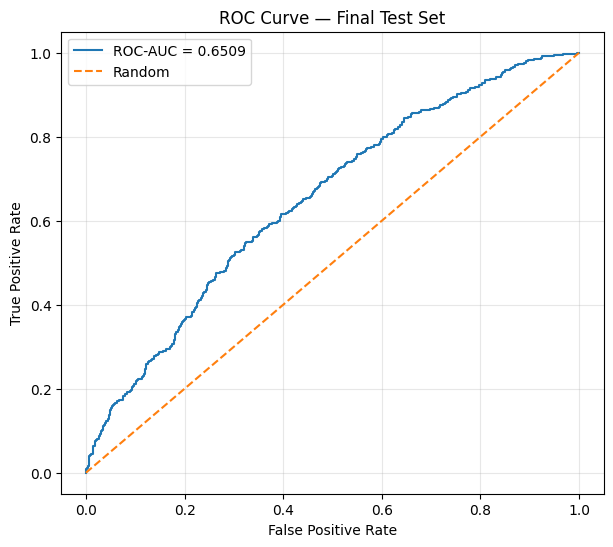

In [62]:
from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(
    y_test,
    test_probs
)

plt.figure(figsize=(7, 6))

plt.plot(
    fpr,
    tpr,
    label=(
        f"ROC-AUC = "
        f"{test_roc_auc:.4f}"
    )
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title(
    "ROC Curve — Final Test Set"
)

plt.legend()
plt.grid(alpha=0.3)

plt.show()

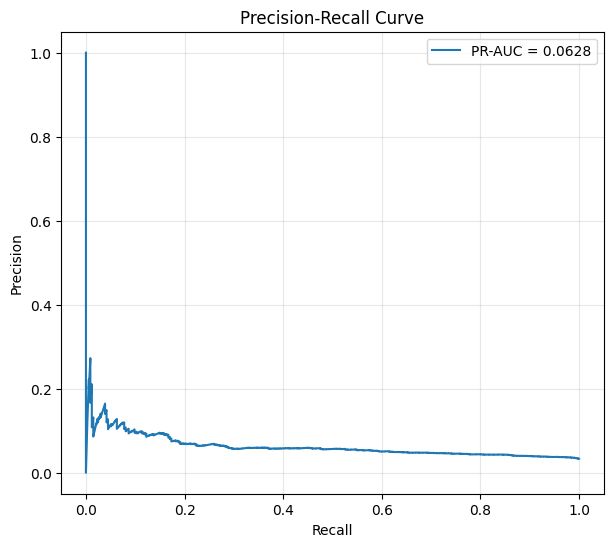

In [63]:
from sklearn.metrics import precision_recall_curve

precision, recall, _ = (
    precision_recall_curve(
        y_test,
        test_probs
    )
)

plt.figure(figsize=(7, 6))

plt.plot(
    recall,
    precision,
    label=(
        f"PR-AUC = "
        f"{test_pr_auc:.4f}"
    )
)

plt.xlabel("Recall")
plt.ylabel("Precision")

plt.title(
    "Precision-Recall Curve"
)

plt.legend()
plt.grid(alpha=0.3)

plt.show()

[[9228  437]
 [ 294   41]]


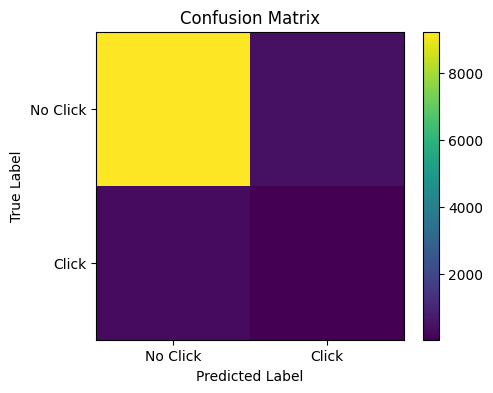

In [65]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test,
    test_predictions
)

print(cm)


plt.figure(figsize=(5, 4))

plt.imshow(cm)

plt.title(
    "Confusion Matrix"
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.xticks(
    [0, 1],
    ["No Click", "Click"]
)

plt.yticks(
    [0, 1],
    ["No Click", "Click"]
)

plt.colorbar()

plt.show()

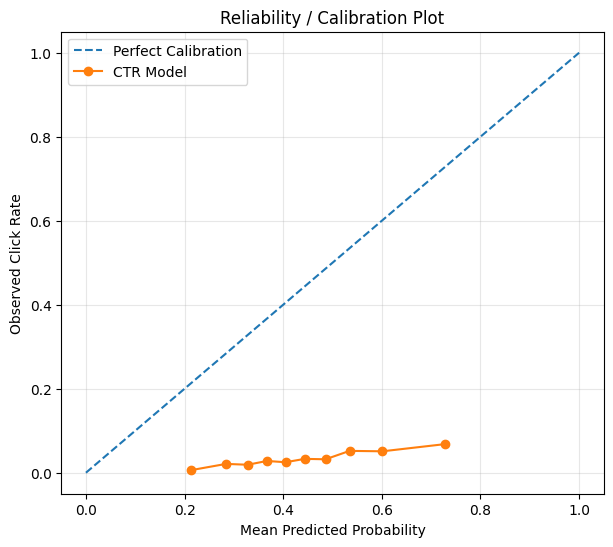

In [66]:
from sklearn.calibration import calibration_curve

prob_true, prob_pred = calibration_curve(
    y_test,
    test_probs,
    n_bins=10,
    strategy="quantile"
)

plt.figure(figsize=(7, 6))

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Perfect Calibration"
)

plt.plot(
    prob_pred,
    prob_true,
    marker="o",
    label="CTR Model"
)

plt.xlabel(
    "Mean Predicted Probability"
)

plt.ylabel(
    "Observed Click Rate"
)

plt.title(
    "Reliability / Calibration Plot"
)

plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [67]:
from sklearn.metrics import brier_score_loss

brier = brier_score_loss(
    y_test,
    test_probs
)

print(
    f"Brier Score: {brier:.6f}"
)

Brier Score: 0.213588


In [68]:
final_results = pd.DataFrame([{

    "Model":
        best_architecture,

    "Threshold":
        best_threshold,

    "ROC-AUC":
        test_roc_auc,

    "PR-AUC":
        test_pr_auc,

    "Accuracy":
        test_accuracy,

    "F1":
        test_f1,

    "Precision":
        test_precision,

    "Recall":
        test_recall,

    "Log Loss":
        test_log_loss,

    "Brier Score":
        brier
}])

display(
    final_results
)

,Model,Threshold,ROC-AUC,PR-AUC,Accuracy,F1,Precision,Recall,Log Loss,Brier Score
0,Medium,0.71,0.650944,0.062835,0.9269,0.100861,0.085774,0.122388,0.620401,0.213588


In [69]:
torch.save(
    {
        "model_state_dict":
            best_model.state_dict(),

        "categorical_columns":
            categorical_cols,

        "numerical_columns":
            numerical_cols,

        "cardinalities":
            cardinality_list,

        "architecture":
            best_architecture,

        "threshold":
            float(best_threshold),

        "scaler":
            scaler,

        "category_maps":
            category_maps
    },
    "best_ctr_model.pt"
)

print(
    "Model saved as best_ctr_model.pt"
)

Model saved as best_ctr_model.pt


In [70]:
submission = pd.DataFrame({

    "ctr_probability":
        test_probs,

    "prediction":
        test_predictions
})

submission.to_csv(
    "ctr_predictions.csv",
    index=False
)

display(
    submission.head(10)
)

print(
    "Saved: ctr_predictions.csv"
)

,ctr_probability,prediction
0,0.322594,0
1,0.365311,0
2,0.489213,0
3,0.181180,0
4,0.609426,0
5,0.310716,0
6,0.690818,0
7,0.452297,0
8,0.413343,0
9,0.465306,0


Saved: ctr_predictions.csv


## DCN Model

In [71]:
class CrossLayer(nn.Module):

    def __init__(self, input_dim):
        super().__init__()

        self.weight = nn.Parameter(
            torch.randn(input_dim) * 0.01
        )

        self.bias = nn.Parameter(
            torch.zeros(input_dim)
        )

    def forward(self, x0, x):

        # Explicit feature crossing
        cross = (
            x0 * x
        ).matmul(
            self.weight
        ).unsqueeze(1)

        return (
            cross + self.bias + x
        )

In [72]:
class DCN(nn.Module):

    def __init__(
        self,
        cardinalities,
        num_numerical,
        deep_dims=(64, 32),
        num_cross_layers=2,
        dropout=0.2
    ):

        super().__init__()

        # -------------------------
        # Embeddings
        # -------------------------

        self.embeddings = nn.ModuleList()

        embedding_dims = []

        for cardinality in cardinalities:

            emb_dim = get_embedding_dim(
                cardinality
            )

            self.embeddings.append(
                nn.Embedding(
                    cardinality,
                    emb_dim
                )
            )

            embedding_dims.append(
                emb_dim
            )

        total_embedding_dim = sum(
            embedding_dims
        )

        self.input_dim = (
            total_embedding_dim
            + num_numerical
        )

        # -------------------------
        # Cross Network
        # -------------------------

        self.cross_layers = nn.ModuleList(
            [
                CrossLayer(self.input_dim)
                for _ in range(num_cross_layers)
            ]
        )

        # -------------------------
        # Deep Network
        # -------------------------

        deep_layers = []

        prev_dim = self.input_dim

        for hidden_dim in deep_dims:

            deep_layers.append(
                nn.Linear(
                    prev_dim,
                    hidden_dim
                )
            )

            deep_layers.append(
                nn.ReLU()
            )

            deep_layers.append(
                nn.Dropout(dropout)
            )

            prev_dim = hidden_dim

        self.deep = nn.Sequential(
            *deep_layers
        )

        # Cross output + Deep output

        self.output = nn.Linear(
            self.input_dim + prev_dim,
            1
        )

    def get_features(
        self,
        numerical,
        categorical
    ):

        embedded_features = []

        for i, embedding in enumerate(
            self.embeddings
        ):

            embedded_features.append(
                embedding(
                    categorical[:, i]
                )
            )

        categorical_vector = torch.cat(
            embedded_features,
            dim=1
        )

        x = torch.cat(
            [
                numerical,
                categorical_vector
            ],
            dim=1
        )

        return x

    def forward(
        self,
        numerical,
        categorical
    ):

        x0 = self.get_features(
            numerical,
            categorical
        )

        # Cross branch

        x_cross = x0

        for layer in self.cross_layers:

            x_cross = layer(
                x0,
                x_cross
            )

        # Deep branch

        x_deep = self.deep(x0)

        # Combine

        combined = torch.cat(
            [
                x_cross,
                x_deep
            ],
            dim=1
        )

        return self.output(
            combined
        ).squeeze(1)

In [73]:
dcn_model = DCN(
    cardinalities=cardinality_list,
    num_numerical=len(numerical_cols),
    deep_dims=(64, 32),
    num_cross_layers=2,
    dropout=0.2
).to(DEVICE)

print(dcn_model)


dcn_model, history_dcn = train_model(
    dcn_model,
    train_loader,
    val_loader,
    pos_weight=pos_weight,
    epochs=8,
    learning_rate=1e-3,
    weight_decay=1e-5,
    patience=2
)

DCN(
  (embeddings): ModuleList(
    (0): Embedding(10858, 32)
    (1): Embedding(3349, 32)
    (2): Embedding(4586, 32)
    (3): Embedding(1614, 32)
    (4): Embedding(3643, 32)
    (5): Embedding(4, 4)
    (6): Embedding(2912, 32)
    (7): Embedding(711, 26)
    (8): Embedding(23, 4)
    (9): Embedding(9625, 32)
    (10): Embedding(4772, 32)
    (11): Embedding(6821, 32)
    (12): Embedding(10, 4)
    (13): Embedding(821, 28)
    (14): Embedding(1833, 32)
    (15): Embedding(43, 6)
    (16): Embedding(5, 4)
    (17): Embedding(310, 17)
    (18): Embedding(15, 4)
    (19): Embedding(11112, 32)
    (20): Embedding(7581, 32)
    (21): Embedding(10423, 32)
    (22): Embedding(4362, 32)
    (23): Embedding(3258, 32)
    (24): Embedding(36, 6)
    (25): Embedding(25, 5)
  )
  (cross_layers): ModuleList(
    (0-1): 2 x CrossLayer()
  )
  (deep): Sequential(
    (0): Linear(in_features=601, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_

In [77]:
dcn_metrics = evaluate_model(
    dcn_model,
    val_loader,
    criterion_weighted
)

print(
    f"ROC-AUC : {dcn_metrics['roc_auc']:.4f}"
)

print(
    f"PR-AUC  : {dcn_metrics['pr_auc']:.4f}"
)

print(
    f"Accuracy: {dcn_metrics['accuracy']:.4f}"
)

print(
    f"F1      : {dcn_metrics['f1']:.4f}"
)

print(f"Log Loss: {log_loss(dcn_metrics['y_true'], dcn_metrics['y_prob']):.4f}")


ROC-AUC : 0.6780
PR-AUC  : 0.0674
Accuracy: 0.7468
F1      : 0.1083
Log Loss: 0.5466


In [78]:
comparison = pd.DataFrame([

    {
        "Model": "Best Vanilla NN",

        "ROC-AUC":
            results_df[
                results_df["Architecture"]
                == best_architecture
            ]["ROC-AUC"].iloc[0],

        "PR-AUC":
            results_df[
                results_df["Architecture"]
                == best_architecture
            ]["PR-AUC"].iloc[0],

        "Accuracy":
            results_df[
                results_df["Architecture"]
                == best_architecture
            ]["Accuracy"].iloc[0],

        "F1":
            results_df[
                results_df["Architecture"]
                == best_architecture
            ]["F1"].iloc[0],

        "Log Loss":
            results_df[
                results_df["Architecture"]
                == best_architecture
            ]["Log Loss"].iloc[0]
    },

    {
        "Model": "DCN",

        "ROC-AUC":
            dcn_metrics["roc_auc"],

        "PR-AUC":
            dcn_metrics["pr_auc"],

        "Accuracy":
            dcn_metrics["accuracy"],

        "F1":
            dcn_metrics["f1"],

        "Log Loss":
            log_loss(
                dcn_metrics["y_true"],
                dcn_metrics["y_prob"]
            )
    }

])

display(comparison)

,Model,ROC-AUC,PR-AUC,Accuracy,F1,Log Loss
0,Best Vanilla NN,0.687050,0.066866,0.68800,0.106017,0.620450
1,DCN,0.677982,0.067356,0.74675,0.108275,0.546595


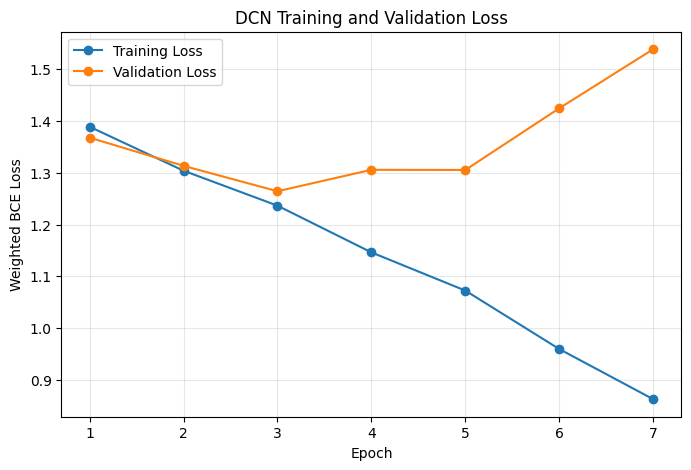

In [80]:
epochs_range = range(
    1,
    len(history_dcn["train_loss"]) + 1
)

plt.figure(figsize=(8, 5))

plt.plot(
    epochs_range,
    history_dcn["train_loss"],
    marker="o",
    label="Training Loss"
)

plt.plot(
    epochs_range,
    history_dcn["val_loss"],
    marker="o",
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Weighted BCE Loss")

plt.title(
    "DCN Training and Validation Loss"
)

plt.xticks(epochs_range)

plt.legend()
plt.grid(alpha=0.3)

plt.show()

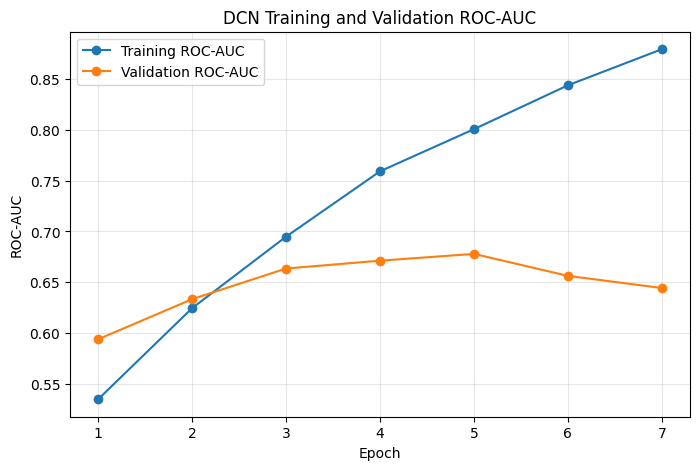

In [81]:
epochs_range = range(
    1,
    len(history_dcn["train_auc"]) + 1
)

plt.figure(figsize=(8, 5))

plt.plot(
    epochs_range,
    history_dcn["train_auc"],
    marker="o",
    label="Training ROC-AUC"
)

plt.plot(
    epochs_range,
    history_dcn["val_auc"],
    marker="o",
    label="Validation ROC-AUC"
)

plt.xlabel("Epoch")
plt.ylabel("ROC-AUC")

plt.title(
    "DCN Training and Validation ROC-AUC"
)

plt.xticks(epochs_range)

plt.legend()
plt.grid(alpha=0.3)

plt.show()